In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Первинне дослідження даних

In [6]:
books = pd.read_csv("bestsellers with categories.csv")
print(books.head())
print(books.shape)

                                                Name  \
0                      10-Day Green Smoothie Cleanse   
1                                  11/22/63: A Novel   
2            12 Rules for Life: An Antidote to Chaos   
3                             1984 (Signet Classics)   
4  5,000 Awesome Facts (About Everything!) (Natio...   

                     Author  User Rating  Reviews  Price  Year        Genre  
0                  JJ Smith          4.7    17350      8  2016  Non Fiction  
1              Stephen King          4.6     2052     22  2011      Fiction  
2        Jordan B. Peterson          4.7    18979     15  2018  Non Fiction  
3             George Orwell          4.7    21424      6  2017      Fiction  
4  National Geographic Kids          4.8     7665     12  2019  Non Fiction  
(550, 7)


**Про скільки книг зберігає дані датасет? Відповідь: про 550 книг**

In [7]:
books.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

In [8]:
print(books.isna().sum())

name           0
author         0
user_rating    0
reviews        0
price          0
year           0
genre          0
dtype: int64


**Чи є в якихось змінних пропуски? Відповідь: ні**

In [9]:
unique_genre = books["genre"].unique()
print(unique_genre)

['Non Fiction' 'Fiction']


**Які є унікальні жанри? Відповідь: 'Non Fiction' 'Fiction'**

Text(0, 0.5, 'Частота')

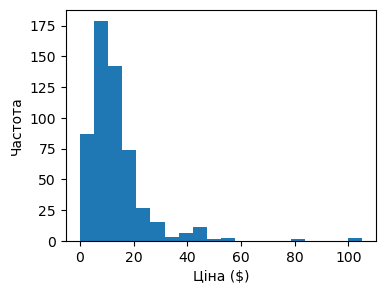

In [19]:
ax = books["price"].plot(kind="hist", bins=20, figsize=(4, 3))
ax.set_xlabel("Ціна ($)")
ax.set_ylabel("Частота")

In [20]:
min_price = books["price"].min()
max_price = books["price"].max()
mean_price = books["price"].mean()
median_price = books["price"].median()
print(min_price)
print(max_price)
print(mean_price)
print(median_price)

0
105
13.1
11.0


**Максимальна ціна? Відповідь: 105
Мінімальна ціна? Відповідь: 0
Середня ціна? Відповідь: 13.1
Медіанна ціна? Відповідь: 11.0**


## Пошук та сортування даних

In [21]:
max_rating = books["user_rating"].max()
print(max_rating)

4.9


**Який рейтинг у датасеті найвищий? Відповідь: 4.9**

In [22]:
books_with_max = books[books["user_rating"] == books["user_rating"].max()].shape[0]
print(books_with_max)

52


**Скільки книг мають такий рейтинг? Відповідь: 52**

In [23]:
more_reviewes = books[books["reviews"] == books["reviews"].max()]["name"]
print(more_reviewes)

534    Where the Crawdads Sing
Name: name, dtype: object


**Яка книга має найбільше відгуків? Відповідь: Where the Crawdads Sing**

In [24]:
top_2015 = books[books["year"] == 2015]
most_expensive = top_2015[top_2015["price"] == top_2015["price"].max()]["name"]
print(most_expensive)

277    Publication Manual of the American Psychologic...
Name: name, dtype: object


**З тих книг, що потрапили до Топ-50 у 2015 році, яка книга найдорожча? Відповідь: Publication Manual of the American Psychologic...**

In [25]:
fiction_2010 = books[(books["year"] == 2010) & (books["genre"] == "Fiction")].shape[0]
print(fiction_2010)

20


**Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році? Відповідь: 20**

In [26]:
rating_in_year = books[
    (books["user_rating"] == 4.9) &
    (books["year"].isin([2010, 2011]))
].shape[0]
print(rating_in_year)

1


**Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках? Відповідь: 1**

In [31]:
to_sort = books[(books["year"] == 2015) & (books["price"] < 8)]
sorted = to_sort.sort_values("price", ascending=True)
print(sorted)
print("----------------")
print(sorted.iloc[-1]["name"])

                                                  name              author  \
507                              To Kill a Mockingbird          Harper Lee   
210                      Laugh-Out-Loud Jokes for Kids         Rob Elliott   
206                         Knock-Knock Jokes for Kids         Rob Elliott   
111                                    First 100 Words        Roger Priddy   
123                               Giraffes Can't Dance       Giles Andreae   
54   Creative Haven Creative Cats Coloring Book (Ad...     Marjorie Sarnat   
63                      Dear Zoo: A Lift-the-Flap Book        Rod Campbell   
89   Dover Creative Haven Art Nouveau Animal Design...         Marty Noble   
478                        The Very Hungry Caterpillar          Eric Carle   
201  Killing Reagan: The Violent Assault That Chang...       Bill O'Reilly   
28                        Baby Touch and Feel: Animals                  DK   
224                                   Love You Forever       Rob

**Яка книга остання у відсортованому списку? Відповідь: Old School (Diary of a Wimpy Kid #10)**

## Агрегування даних та з'єднання таблиць

In [32]:
prices = books.groupby("genre")["price"].agg(["min", "max"])
print(prices)

             min  max
genre                
Fiction        0   82
Non Fiction    0  105


**Максимальна ціна для жанру Fiction: Відповідь: 82
Мінімальна ціна для жанру Fiction: Відповідь: 0
Максимальна ціна для жанру Non Fiction: Відповідь: 105
Мінімальна ціна для жанру Non Fiction: Відповідь: 0**

In [36]:
count_for_author = books.groupby("author")["name"].agg(["count"])

print(count_for_author)
print(count_for_author["count"].idxmax())
print(count_for_author["count"].max())

                            count
author                           
Abraham Verghese                2
Adam Gasiewski                  1
Adam Mansbach                   1
Adir Levy                       1
Admiral William H. McRaven      1
...                           ...
Walter Isaacson                 3
William Davis                   2
William P. Young                2
Wizards RPG Team                3
Zhi Gang Sha                    2

[248 rows x 1 columns]
Jeff Kinney
12


**Якої розмірності вийшла таблиця? Відповідь: (248, 1)
Який автор має найбільше книг? Відповідь: Jeff Kinney
Скільки книг цього автора? Відповідь: 12**

In [40]:
mean_rating = books.groupby("author")["user_rating"].agg(["mean"])
print(mean_rating)
print(mean_rating["mean"].idxmin())
print(mean_rating["mean"].min())

                                mean
author                              
Abraham Verghese            4.600000
Adam Gasiewski              4.400000
Adam Mansbach               4.800000
Adir Levy                   4.800000
Admiral William H. McRaven  4.700000
...                              ...
Walter Isaacson             4.566667
William Davis               4.400000
William P. Young            4.600000
Wizards RPG Team            4.800000
Zhi Gang Sha                4.600000

[248 rows x 1 columns]
Donna Tartt
3.9


**У якого автора середній рейтинг мінімальний? Відповідь: Donna Tartt
Відповідь: Який у цього автора середній рейтинг? Відповідь: 3.9**

In [44]:
concat = pd.concat([count_for_author, mean_rating], axis = 1)
sort_table = concat.sort_values(["count", "mean"])
print(sort_table)

                                    count      mean
author                                             
Muriel Barbery                          1  4.000000
Chris Cleave                            1  4.100000
Ian K. Smith M.D.                       1  4.100000
Pierre Dukan                            1  4.100000
Elizabeth Strout                        1  4.200000
...                                   ...       ...
American Psychological Association     10  4.500000
Suzanne Collins                        11  4.663636
Gary Chapman                           11  4.736364
Rick Riordan                           11  4.772727
Jeff Kinney                            12  4.800000

[248 rows x 2 columns]


**Який автор перший у списку? Відповідь: Muriel Barbery**

## Візуалізація

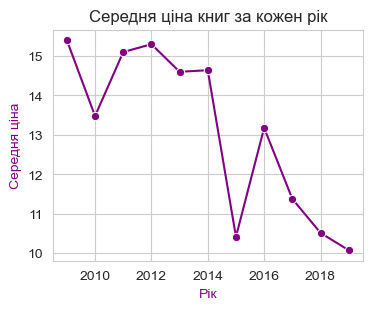

In [46]:
price_by_year = books.groupby("year")["price"].agg(["mean"])
sns.set_style("whitegrid")
plt.figure(figsize=(4, 3))
sns.lineplot(x = price_by_year.index, y = price_by_year["mean"], data=price_by_year, marker="o", color = "purple")
plt.title("Середня ціна книг за кожен рік")
plt.xlabel("Рік", color = "purple")
plt.ylabel("Середня ціна", color = "purple")
plt.show()

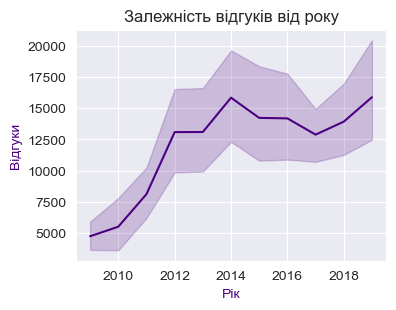

In [50]:
sns.set_style("darkgrid")
plt.figure(figsize=(4, 3))
sns.lineplot(
    data=books,
    x="year",
    y="reviews",
    color = "indigo"
)
plt.title("Залежність відгуків від року")
plt.xlabel("Рік", color = "indigo")
plt.ylabel("Відгуки", color = "indigo")
plt.show()

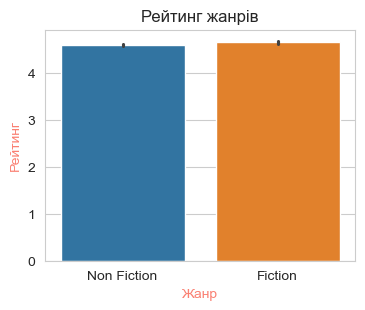

In [51]:
sns.set_style("whitegrid")
plt.figure(figsize=(4, 3))
sns.barplot(x="genre", y="user_rating", data=books, hue = "genre")
plt.title("Рейтинг жанрів")
plt.xlabel("Жанр", color = "salmon")
plt.ylabel("Рейтинг", color = "salmon")
plt.show()